In [1]:
import re
from pathlib import Path
import cv2

NUCLEAR_FOLDER = "Nuclear Opalescence - Color"
CORTICAL_FOLDER = "Retroillumination - CC"
PSC_FOLDER = "Retroillumination - PSC"

_NUCLEAR_PATTERN = re.compile(r"^NO(\d+)-NC(\d+)$", re.IGNORECASE)
_CC_PATTERN = re.compile(r"^CC(\d+)(\.1)?$", re.IGNORECASE)
_PSC_PATTERN = re.compile(r"^PSC(\d+)(\.1)?$", re.IGNORECASE)

def _stem_without_all_suffixes(filename: str) -> str:
    """'CC1.1.png' -> 'CC1.1'; 'CC1.1' (no ext) -> 'CC1.1'; 'CC0.png' -> 'CC0'."""
    p = Path(filename)
    if p.suffix.lower() in (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"):
        return p.stem
    return filename

def _is_probably_image(path: Path) -> bool:
    try:
        with open(path, "rb") as f:
            header = f.read(12)
    except OSError:
        return False
    signatures = [
        b"\x89PNG\r\n\x1a\n",   
        b"\xff\xd8\xff",         
        b"BM",                    
        b"II*\x00", b"MM\x00*",  
    ]
    return any(header.startswith(sig) for sig in signatures)

def _scan_folder(folder: Path, pattern: re.Pattern, cataract_type: str,
                  grade_group: int = 1) -> list:
    entries = []
    skipped_non_image = []
    for path in sorted(folder.iterdir()):
        if not path.is_file():
            continue
        stem = _stem_without_all_suffixes(path.name)
        m = pattern.match(stem)
        if not m:
            continue
        if not _is_probably_image(path):
            skipped_non_image.append(path.name)
            continue
        grade = int(m.group(grade_group))
        is_duplicate = bool(m.lastindex and m.lastindex >= 2 and m.group(m.lastindex) == ".1") \
            if pattern in (_CC_PATTERN, _PSC_PATTERN) else False
        entries.append({
            "path": str(path),
            "grade": grade,
            "cataract_type": cataract_type,
            "is_duplicate": is_duplicate,
        })
    if skipped_non_image:
        print(f"[load_dataset] WARNING - matched filename pattern but failed image-header "
              f"check, skipped: {skipped_non_image}")
    return entries

def load_optiscan_dataset(root_dir: str) -> dict:
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Dataset root not found: {root_dir}")

    nuclear_dir = root / NUCLEAR_FOLDER
    cortical_dir = root / CORTICAL_FOLDER
    psc_dir = root / PSC_FOLDER

    manifests = {}

    if nuclear_dir.exists():
        entries = []
        for path in sorted(nuclear_dir.iterdir()):
            if not path.is_file() or not _is_probably_image(path):
                continue
            stem = _stem_without_all_suffixes(path.name)
            m = _NUCLEAR_PATTERN.match(stem)
            if not m:
                continue
            grade_no, grade_nc = int(m.group(1)), int(m.group(2))
            if grade_no != grade_nc:
                print(f"[load_dataset] WARNING - {path.name}: NO grade ({grade_no}) != "
                      f"NC grade ({grade_nc}), using NO grade. Check this file.")
            entries.append({
                "path": str(path),
                "grade": grade_no,
                "cataract_type": "nuclear",
                "is_duplicate": False,
            })
        manifests["nuclear"] = entries
    else:
        print(f"[load_dataset] '{NUCLEAR_FOLDER}' not found under {root_dir}")
        manifests["nuclear"] = []

    if cortical_dir.exists():
        manifests["cortical"] = _scan_folder(cortical_dir, _CC_PATTERN, "cortical")
    else:
        print(f"[load_dataset] '{CORTICAL_FOLDER}' not found under {root_dir}")
        manifests["cortical"] = []

    if psc_dir.exists():
        manifests["psc"] = _scan_folder(psc_dir, _PSC_PATTERN, "psc")
    else:
        print(f"[load_dataset] '{PSC_FOLDER}' not found under {root_dir}")
        manifests["psc"] = []

    return manifests


def summarize(manifests: dict) -> str:
    lines = []
    for cataract_type, entries in manifests.items():
        grades = sorted(set(e["grade"] for e in entries))
        n_dup = sum(1 for e in entries if e.get("is_duplicate"))
        lines.append(
            f"{cataract_type:10s}: {len(entries):2d} images, "
            f"grades present={grades}, duplicates={n_dup}"
        )
        if cataract_type == "nuclear" and 0 not in grades:
            lines.append("             NOTE: no grade-0 (no-cataract) reference image present.")
        expected_full_range = set(range(0, 7)) if cataract_type == "nuclear" else set(range(0, 6))
        missing = expected_full_range - set(grades)
        if missing and cataract_type != "nuclear":
            lines.append(f"             NOTE: no images for grade(s) {sorted(missing)}.")
    return "\n".join(lines)


def load_image(entry: dict):
    """cv2.imread wrapper — works regardless of the file's (missing/wrong) extension."""
    img = cv2.imread(entry["path"])
    if img is None:
        raise IOError(f"cv2 could not decode {entry['path']} despite passing the header sniff — "
                       f"file may be corrupted or a genuinely unsupported format.")
    return img

In [3]:
DATASET_ROOT = r"C:\Users\Kyle\Downloads\optiscan try\archive\Dataset-20260802T063315Z-1-001\Dataset"

manifests = load_optiscan_dataset(DATASET_ROOT)
print(summarize(manifests))

nuclear   :  7 images, grades present=[0, 1, 2, 3, 4, 5, 6], duplicates=0
cortical  : 10 images, grades present=[0, 1, 2, 3, 4, 5], duplicates=4
psc       :  9 images, grades present=[0, 1, 2, 3, 4, 5], duplicates=3


In [4]:
print(manifests.keys())

dict_keys(['nuclear', 'cortical', 'psc'])


In [5]:
from pathlib import Path

folder = Path(DATASET_ROOT) / "Retroillumination - CC"

for f in sorted(folder.iterdir()):
    if f.suffix == ".1":
        with open(f, "rb") as file:
            print(f.name, file.read(8))

from pathlib import Path

for folder_name in ["Retroillumination - CC", "Retroillumination - PSC"]:
    folder = Path(DATASET_ROOT) / folder_name

    for f in folder.iterdir():
        if f.suffix == ".1":
            new_name = f.with_name(f.name + ".png")  # CC1.1 -> CC1.1.png
            f.rename(new_name)
            print(f"{f.name} -> {new_name.name}")

In [6]:
from pathlib import Path

for f in sorted((Path(DATASET_ROOT) / "Retroillumination - CC").iterdir()):
    print(repr(f.name), "stem =", Path(f.name).stem, "suffix =", Path(f.name).suffix)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def _stem_without_all_suffixes(filename: str) -> str:
    p = Path(filename)

    if p.suffix.lower() in IMAGE_EXTS:
        return p.stem
    return p.name


'CC0.png' stem = CC0 suffix = .png
'CC1.1.png' stem = CC1.1 suffix = .png
'CC1.png' stem = CC1 suffix = .png
'CC2.1.png' stem = CC2.1 suffix = .png
'CC2.png' stem = CC2 suffix = .png
'CC3.1.png' stem = CC3.1 suffix = .png
'CC3.png' stem = CC3 suffix = .png
'CC4.1.png' stem = CC4.1 suffix = .png
'CC4.png' stem = CC4 suffix = .png
'CC5.png' stem = CC5 suffix = .png


In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [8]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd()  
if not (PROJECT_ROOT / "roi").exists():
    PROJECT_ROOT = PROJECT_ROOT / "optiscan"
sys.path.insert(0, str(PROJECT_ROOT))

def show(img_bgr, title="", figsize=(5, 5)):
    plt.figure(figsize=figsize)
    if img_bgr.ndim == 2:
        plt.imshow(img_bgr, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_grid(images, titles=None, cols=4, figsize_per=(2.5, 2.5)):
    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per[0]*cols, figsize_per[1]*rows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            img = images[i]
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img, cmap="gray")
            if titles: ax.set_title(titles[i], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Kyle\Downloads\optiscan try\optiscan


In [9]:
image_path = r"c:\Users\Kyle\Downloads\optiscan try\archive\Nuclear Cataract Database for Biomedical and Machine Learning Applications\Nuclear Cataract Database for Biomedical and Machine Learning Applications\Nuclear Cataract Dataset\81\DER\IM000000.JPG"
real_img = cv2.imread(image_path)
cv2.imread(r"C:\Users\Kyle\Downloads\optiscan try\archive\Dataset-20260802T063315Z-1-001\Dataset\Retroillumination - CC\CC5.png")

array([[[27, 29, 29],
        [27, 29, 29],
        [27, 29, 29],
        ...,
        [25, 30, 29],
        [25, 30, 29],
        [25, 30, 29]],

       [[27, 29, 29],
        [27, 29, 29],
        [27, 29, 29],
        ...,
        [25, 30, 29],
        [25, 30, 29],
        [25, 30, 29]],

       [[27, 29, 29],
        [27, 29, 29],
        [27, 29, 29],
        ...,
        [25, 30, 29],
        [25, 30, 29],
        [25, 30, 29]],

       ...,

       [[25, 30, 29],
        [25, 30, 29],
        [25, 30, 29],
        ...,
        [25, 30, 29],
        [25, 30, 29],
        [25, 30, 29]],

       [[25, 30, 29],
        [25, 30, 29],
        [25, 30, 29],
        ...,
        [25, 30, 29],
        [25, 30, 29],
        [25, 30, 29]],

       [[25, 30, 29],
        [25, 30, 29],
        [25, 30, 29],
        ...,
        [25, 30, 29],
        [25, 30, 29],
        [25, 30, 29]]], shape=(474, 372, 3), dtype=uint8)

Detected circle ROI: CircleROI(cx=1520, cy=1177, radius=610, bbox=(910, 567, 1220, 1220))


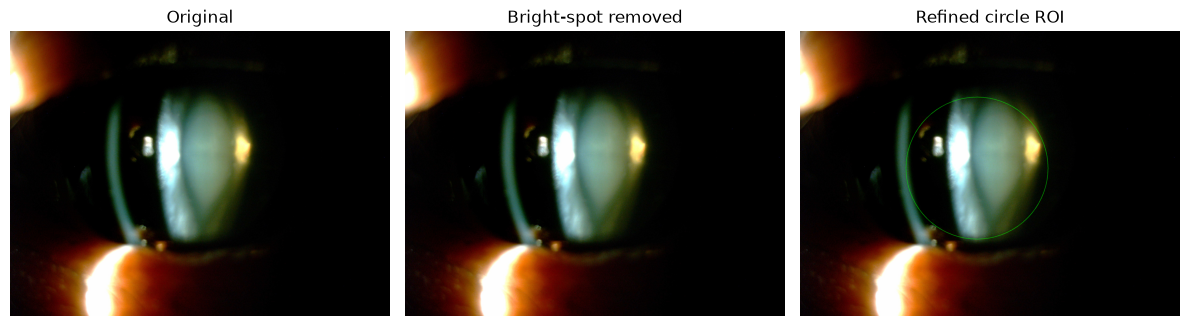

In [10]:
from roi.retro_roi import detect_lens_roi_retro, crop_to_circle, remove_bright_spots

cleaned, circle_roi = detect_lens_roi_retro(real_img)
print("Detected circle ROI:", circle_roi)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB)); axes[1].set_title("Bright-spot removed"); axes[1].axis("off")
vis = cleaned.copy()
cv2.circle(vis, (circle_roi.cx, circle_roi.cy), circle_roi.radius, (0, 255, 0), 2)
axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); axes[2].set_title("Refined circle ROI"); axes[2].axis("off")
plt.tight_layout(); plt.show()

Fitted ellipse ROI: EllipseROI(cx=np.float64(1156.5463597459827), cy=np.float64(1734.5085292341892), a=np.float64(908.8296439601605), b=np.float64(1383.4687681801433), theta=np.float64(-2.5837848117659257), bbox=(247, 351, 1817, 2766))


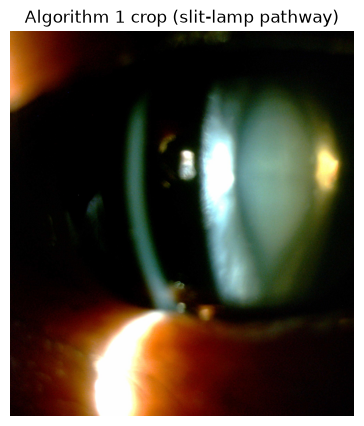

In [11]:
from roi.slit_lamp_roi import detect_lens_roi_slit_lamp, crop_to_roi

try:
    ellipse_roi = detect_lens_roi_slit_lamp(real_img)
    print("Fitted ellipse ROI:", ellipse_roi)
    cropped = crop_to_roi(real_img, ellipse_roi)
    show(cropped, "Algorithm 1 crop (slit-lamp pathway)")
except RuntimeError as e:
    print("Algorithm 1 needs a real slit-lamp image with clearer edges:", e)

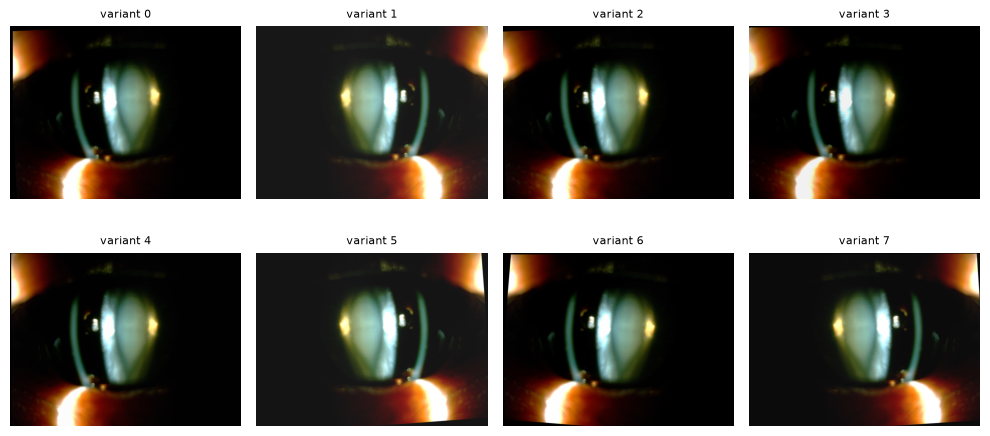

In [12]:
from augmentation.augment import augment_image_set

variants = augment_image_set(real_img, cataract_type="cortical", n_variants=8)
show_grid(variants, titles=[f"variant {i}" for i in range(len(variants))], cols=4)

In [13]:
from data.grade_scale_mapping import SourceScale, build_label_manifest
from data.split import stratified_split, leave_one_out_splits, summarize_split

demo_entries = [
    {"path": "std_grade0.jpg", "scale": SourceScale.STANDARD_0_6, "raw_value": 0},
    {"path": "std_grade3.jpg", "scale": SourceScale.STANDARD_0_6, "raw_value": 3},
    {"path": "std_grade6.jpg", "scale": SourceScale.STANDARD_0_6, "raw_value": 6},
    {"path": "locsC_1.4.jpg",  "scale": SourceScale.LOCS_C, "raw_value": 1.4},
    {"path": "locsC_3.2.jpg",  "scale": SourceScale.LOCS_C, "raw_value": 3.2},
    {"path": "locsP_2.0.jpg",  "scale": SourceScale.LOCS_P, "raw_value": 2.0},
    {"path": "locsP_5.0.jpg",  "scale": SourceScale.LOCS_P, "raw_value": 5.0},
]
manifest = build_label_manifest(demo_entries)
for e in manifest:
    print(f"{e['path']:16s}  scale={e['scale'].value:14s}  raw={e['raw_value']}  -> standard_grade={e['standard_grade']}")

train, test = stratified_split(manifest, test_frac=0.2)
print()
print(summarize_split(train, "train"))
print(summarize_split(test, "test"))

print()
print("Leave-one-out folds (recommended eval strategy at this sample size):")
for i, (tr, held) in enumerate(leave_one_out_splits(manifest)):
    print(f"  fold {i}: held out {held[0]['path']}, train size={len(tr)}")

std_grade0.jpg    scale=standard_0_6    raw=0  -> standard_grade=0
std_grade3.jpg    scale=standard_0_6    raw=3  -> standard_grade=3
std_grade6.jpg    scale=standard_0_6    raw=6  -> standard_grade=6
locsC_1.4.jpg     scale=locs_c_0_5      raw=1.4  -> standard_grade=2
locsC_3.2.jpg     scale=locs_c_0_5      raw=3.2  -> standard_grade=4
locsP_2.0.jpg     scale=locs_p_0_5      raw=2.0  -> standard_grade=4
locsP_5.0.jpg     scale=locs_p_0_5      raw=5.0  -> standard_grade=6

train (n=5): grade 0: 1, grade 2: 1, grade 3: 1, grade 4: 1, grade 6: 1
test (n=2): grade 4: 1, grade 6: 1

Leave-one-out folds (recommended eval strategy at this sample size):
  fold 0: held out std_grade0.jpg, train size=6
  fold 1: held out std_grade3.jpg, train size=6
  fold 2: held out std_grade6.jpg, train size=6
  fold 3: held out locsC_1.4.jpg, train size=6
  fold 4: held out locsC_3.2.jpg, train size=6
  fold 5: held out locsP_2.0.jpg, train size=6
  fold 6: held out locsP_5.0.jpg, train size=6


cataract_type: cortical
grade: 1
grade_label: Grade 1 (total area 0.4%)
circumference_grade: COR-3
central_zone_involved: True
confidence: None
roi_bbox: (910, 567, 1220, 1220)
monitor: True


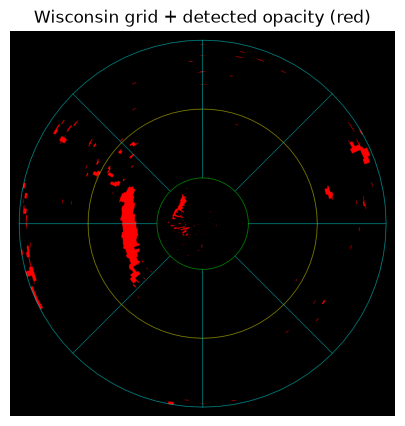

In [14]:
from pipeline import run_cortical

result = run_cortical(real_img)
overlay = result.pop("explainability_overlay")
for k, v in result.items():
    print(f"{k}: {v}")
show(overlay, "Wisconsin grid + detected opacity (red)")

cataract_type: psc
grade: 0
grade_label: Grade 0 - no cataract detected
vertical_diameter_mm: 0.03
visualizable: True
within_central_zone: False
confidence: None
roi_bbox: (910, 567, 1220, 1220)
monitor: False


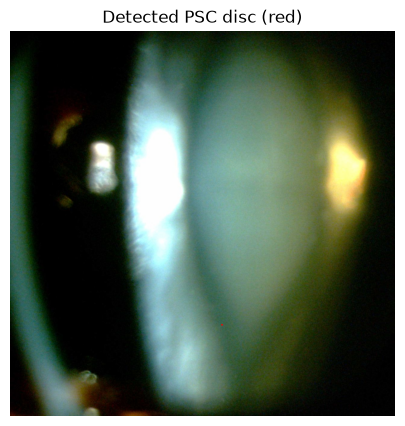

In [15]:
from pipeline import run_psc

result = run_psc(real_img)
overlay = result.pop("explainability_overlay")
for k, v in result.items():
    print(f"{k}: {v}")
show(overlay, "Detected PSC disc (red)")

In [16]:
MODEL_PATH = PROJECT_ROOT / "vgg11.tflite"

import tensorflow as tf
Interpreter = tf.lite.Interpreter

if not MODEL_PATH.exists():
    print(f"'{MODEL_PATH.name}' not found in {PROJECT_ROOT} — building a random-weight ")
    print("placeholder ONLY so this cell runs end-to-end. Upload your real vgg11.tflite ")
    print("to this folder and re-run this cell to get real predictions.")
    import tensorflow as tf
    from tensorflow import keras
    from keras import layers

    inputs = keras.Input(shape=(224, 224, 3))
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="relu", name="embedding")(x)
    outputs = layers.Dense(7, activation="softmax")(x)
    placeholder_model = keras.Model(inputs, outputs)
    converter = tf.lite.TFLiteConverter.from_keras_model(placeholder_model)
    MODEL_PATH = PROJECT_ROOT / "_placeholder_vgg11.tflite"
    with open(MODEL_PATH, "wb") as f:
        f.write(converter.convert())
else:
    print(f"Found real model at {MODEL_PATH}")

from grading.nuclear_vgg11 import VGG11TFLiteBackbone
backbone = VGG11TFLiteBackbone(str(MODEL_PATH))
print()
print("Model I/O signature (CHECK THIS against your real model before trusting predictions):")
print(backbone.describe())

Found real model at c:\Users\Kyle\Downloads\optiscan try\optiscan\vgg11.tflite

Model I/O signature (CHECK THIS against your real model before trusting predictions):
{'inputs': [{'name': 'serving_default_input:0', 'index': 0, 'shape': array([  1,   3, 224, 224], dtype=int32), 'shape_signature': array([ -1,   3, 224, 224], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}], 'outputs': [{'name': 'PartitionedCall:0', 'index': 82, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]}


In [17]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path=str(MODEL_PATH))
interpreter.allocate_tensors()

print(interpreter.get_input_details())

c:\Users\Kyle\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[{'name': 'serving_default_input:0', 'index': 0, 'shape': array([  1,   3, 224, 224], dtype=int32), 'shape_signature': array([ -1,   3, 224, 224], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [18]:
print(backbone.input_details[0]['shape'])
print(backbone.input_details[0]['dtype'])

[  1   3 224 224]
<class 'numpy.float32'>


In [19]:
import importlib
import grading.nuclear_vgg11 as nv
importlib.reload(nv)

backbone2 = nv.VGG11TFLiteBackbone(str(MODEL_PATH))
test_input = backbone2.preprocess(real_img)
print("preprocess() output shape:", test_input.shape, test_input.dtype)

preprocess() output shape: (1, 3, 224, 224) float32


In [20]:
import grading.nuclear_vgg11 as nv
backbone2 = nv.VGG11TFLiteBackbone(str(MODEL_PATH))
test_input = backbone2.preprocess(real_img)
print("preprocess() output shape:", test_input.shape, test_input.dtype)

preprocess() output shape: (1, 3, 224, 224) float32


cataract_type: nuclear
grade: 1
grade_label: Grade 1 - cataract detected, monitor
confidence: 0.665
class_probabilities: [0.2157568782567978, 0.6649355888366699, 0.02172359637916088, 0.013986218720674515, 0.05281095951795578, 0.030786607414484024]
roi_bbox: (247, 351, 1817, 2766)
monitor: True


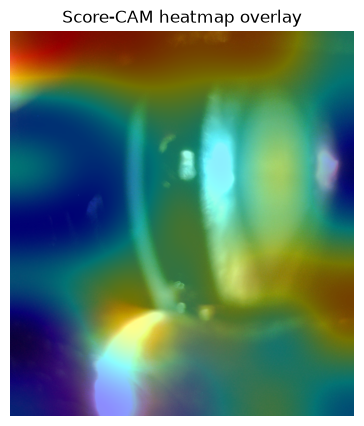

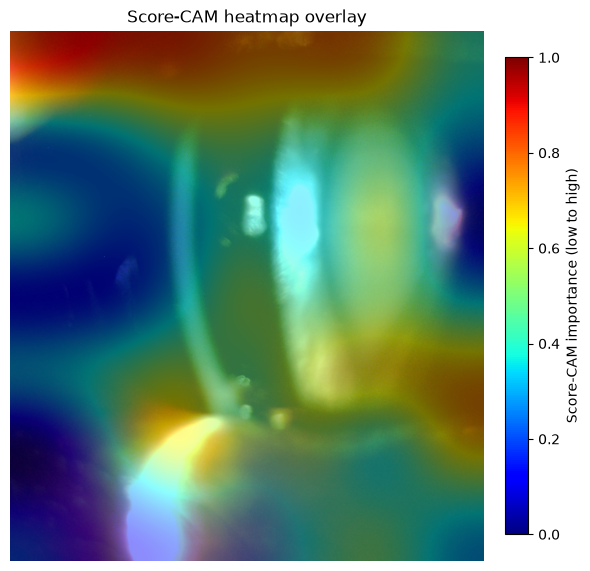

In [24]:
from pipeline import run_nuclear

result = run_nuclear(real_img, model_path=str(MODEL_PATH))
overlay = result.pop("explainability_overlay")
for k, v in result.items():
    print(f"{k}: {v}")
show(overlay, "Score-CAM heatmap overlay")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
ax.set_title("Score-CAM heatmap overlay")
ax.axis("off")

# Colorbar showing what the JET colors mean, matched to the same
# colormap/range used to generate the heatmap overlay (0=low importance,
# 1=high importance to the predicted grade).
sm = cm.ScalarMappable(cmap="jet", norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Score-CAM importance (low to high)")

plt.tight_layout()
plt.show()

=== CORTICAL ===
  cataract_type: cortical
  grade: 1
  grade_label: Grade 1 (total area 0.4%)
  circumference_grade: COR-3
  central_zone_involved: True
  confidence: None
  roi_bbox: (910, 567, 1220, 1220)
  monitor: True


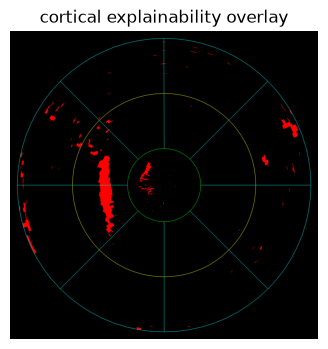


=== PSC ===
  cataract_type: psc
  grade: 0
  grade_label: Grade 0 - no cataract detected
  vertical_diameter_mm: 0.03
  visualizable: True
  within_central_zone: False
  confidence: None
  roi_bbox: (910, 567, 1220, 1220)
  monitor: False


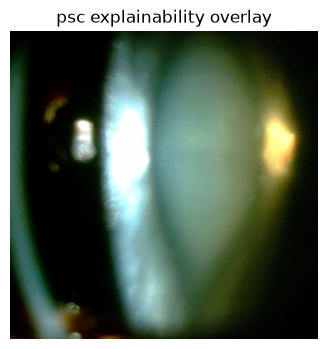


=== NUCLEAR ===
  cataract_type: nuclear
  grade: 1
  grade_label: Grade 1 - cataract detected, monitor
  confidence: 0.665
  class_probabilities: [0.2157568782567978, 0.6649355888366699, 0.02172359637916088, 0.013986218720674515, 0.05281095951795578, 0.030786607414484024]
  roi_bbox: (247, 351, 1817, 2766)
  monitor: True


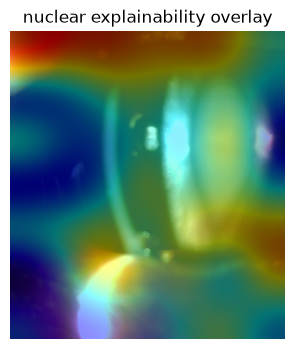

In [25]:
import cv2
TEST_IMAGE_PATH = r"C:\Users\Kyle\Downloads\optiscan try\archive\Dataset-20260802T063315Z-1-001\Dataset\Retroillumination - CC\CC2.png"
cv2.imwrite(TEST_IMAGE_PATH, real_img)

from pipeline import grade_image

for cataract_type in ["cortical", "psc", "nuclear"]:
    print(f"=== {cataract_type.upper()} ===")
    kwargs = {"model_path": str(MODEL_PATH)} if cataract_type == "nuclear" else {}
    result = grade_image(TEST_IMAGE_PATH, cataract_type, **kwargs)
    overlay = result.pop("explainability_overlay")
    for k, v in result.items():
        print(f"  {k}: {v}")
    show(overlay, f"{cataract_type} explainability overlay", figsize=(4, 4))
    print()